In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Load dataset
df = pd.read_csv('oral_cancer_prediction_dataset.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (84922, 25)

First 5 rows:


,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [3]:
# Check missing values and data types
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 ID                                          0
Country                                     0
Age                                         0
Gender                                      0
Tobacco Use                                 0
Alcohol Consumption                         0
HPV Infection                               0
Betel Quid Use                              0
Chronic Sun Exposure                        0
Poor Oral Hygiene                           0
Diet (Fruits & Vegetables Intake)           0
Family History of Cancer                    0
Compromised Immune System                   0
Oral Lesions                                0
Unexplained Bleeding                        0
Difficulty Swallowing                       0
White or Red Patches in Mouth               0
Tumor Size (cm)                             0
Cancer Stage                                0
Treatment Type                              0
Survival Rate (5-Year, %)                   0
Cost of Treatment

Oral Cancer (Diagnosis)
No     42573
Yes    42349
Name: count, dtype: int64


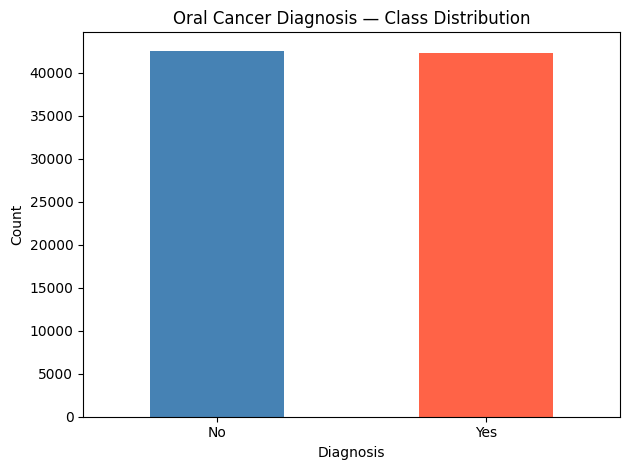

In [4]:
# Target class distribution
print(df['Oral Cancer (Diagnosis)'].value_counts())

df['Oral Cancer (Diagnosis)'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Oral Cancer Diagnosis — Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
df_clean = df.copy()

# Drop irrelevant columns
df_clean.drop(columns=['ID', 'Country', 'Treatment Type', 
                        'Survival Rate (5-Year, %)', 
                        'Cost of Treatment (USD)', 
                        'Economic Burden (Lost Workdays per Year)'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Features & Target
X = df_clean.drop(columns=['Oral Cancer (Diagnosis)'])
y = df_clean['Oral Cancer (Diagnosis)']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features:", X.columns.tolist())
print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nPreprocessing complete!")

C:\Users\USER\AppData\Local\Temp\ipykernel_23396\3364169636.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include='object').columns


Features: ['Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure', 'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)', 'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions', 'Unexplained Bleeding', 'Difficulty Swallowing', 'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage', 'Early Diagnosis']

Train size: (67937, 18)
Test size: (16985, 18)

Preprocessing complete!


In [9]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Results
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8515
           1       1.00      1.00      1.00      8470

    accuracy                           1.00     16985
   macro avg       1.00      1.00      1.00     16985
weighted avg       1.00      1.00      1.00     16985



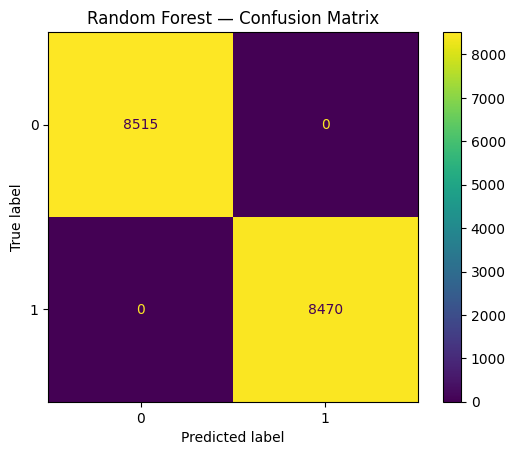

In [10]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('Random Forest — Confusion Matrix')
plt.show()

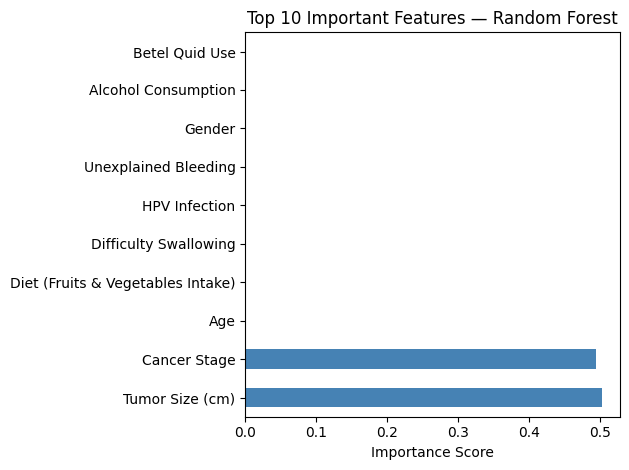

In [11]:
# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred_rf)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

# Confusion Matrix values
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print("=" * 40)
print("   RANDOM FOREST — RESULTS SUMMARY")
print("=" * 40)
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("-" * 40)
print("Confusion Matrix:")
print(f"  True Negative  (TN): {tn}")
print(f"  False Positive (FP): {fp}")
print(f"  False Negative (FN): {fn}")
print(f"  True Positive  (TP): {tp}")
print("=" * 40)

   RANDOM FOREST — RESULTS SUMMARY
Accuracy  : 1.0000 (100.00%)
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
----------------------------------------
Confusion Matrix:
  True Negative  (TN): 8515
  False Positive (FP): 0
  False Negative (FN): 0
  True Positive  (TP): 8470
